# Insurance Claim Analytics: Cost Drivers, Risk Segmentation and Predictive Modeling  


## 1. Introduction

Insurance companies need to understand what drives healthcare costs in order to make better decisions around pricing, risk management and customer strategy.

At the same time, these decisions are not only about costs, but also about understanding people’s health profiles and how different risk factors interact.

In this project, I explore a health insurance dataset to better understand the main drivers of medical expenses and how these insights can support more informed and balanced decisions.

The analysis focuses on three main goals:

- understanding what drives healthcare costs  
- identifying different risk profiles across the population  
- building models to estimate costs and identify individuals with a higher likelihood of generating high-cost claims


To do this, I combine exploratory analysis, segmentation techniques, causal inference and predictive modeling, including both **regression and classification** approaches.


The goal is to connect data analysis with practical insights that can support both business decisions and a more informed understanding of risk.


## 2. Business Context

In the insurance industry, understanding customer risk is essential to support decisions around pricing, portfolio management and long-term sustainability.

Healthcare costs are not evenly distributed across the population. A relatively small group of customers may generate significantly higher expenses, often driven by a combination of demographic and lifestyle factors.

From a business perspective, being able to identify these patterns early can help insurers:


- improve cost forecasting  
- design more balanced pricing strategies  
- better understand different customer profiles  
- support more targeted and efficient interventions  

At the same time, these insights should be used carefully. Risk models should not only aim to manage costs, but also support more informed and responsible decision-making.

In addition to cost management, understanding risk patterns can also help identify opportunities for earlier interventions and more proactive approaches to health.

In this context, this project explores how data analysis and predictive modeling can help better **understand healthcare cost dynamics** and **identify different levels of risk** and potential cost exposure across the insured population.



## 3. Dataset Overview

This project uses a public health insurance dataset originally published on Kaggle. It contains demographic and lifestyle information about insured individuals along with their annual medical costs.

**Source**: https://www.kaggle.com/datasets/mirichoi0218/insurance

### 3.1. Loading the data

The dataset is loaded and prepared for analysis. The first rows of the dataset are shown below.

In [33]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Colab Notebooks/10.Health_Insurance/insurance.csv'
df = pd.read_csv(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Main variables:

- `age` — age of the insured individual
- `sex` — gender
- `bmi` — body mass index
- `children` — number of dependents
- `smoker` — smoking status
- `region` — geographic region
- `charges` — annual medical insurance costs

### 3.2 Initial Inspection

Before starting the analysis, an initial inspection is performed to understand the structure and quality of the dataset.

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


The dataset contains:

- **1338** observations
- **7** variables
- No missing values

The target variable used in this analysis is `charges`, representing annual medical costs.

This variable will also be used to derive a proxy for **claim risk** in later stages of the analysis.

## 4. Data Governance and Responsible Use

Health data is highly sensitive and requires careful handling.

Even though the dataset used in this project is anonymized, real-world healthcare analytics must consider several important governance principles, including:

- secure data storage
- anonymization of personal data
- compliance with regulations such as **GDPR (Europe)** and **LGPD (Brazil)**

Predictive models in healthcare can also raise ethical concerns, especially if used to adjust insurance pricing or restrict coverage for higher-risk individuals.

In this project, the focus is on using data to **better understand risk patterns** and **support more informed and responsible decision-making**, rather than relying on purely cost-driven approaches.

## 5. Data Exploration (SQL + EDA)

The analysis begins with an initial exploration of the dataset using both SQL and Python.

This step helps identify early patterns and understand how healthcare costs are distributed across different groups.

The dataset is first loaded into a SQLite database and explored using SQL queries.


In [35]:
import sqlite3
conn = sqlite3.connect("insurance.db")
df.to_sql("insurance", conn, if_exists="replace", index=False)
pd.read_sql("SELECT COUNT(*) as n_rows FROM insurance;", conn)

,n_rows
0,1338


### 5.1 Smoking Status and Healthcare Costs

The first analysis compares healthcare costs between **smokers** and **non-smokers**.

In [36]:
query = """
SELECT smoker, COUNT(*) AS population,
  ROUND(AVG(charges), 2) AS avg_cost, ROUND(MIN(charges), 2) AS min_cost, ROUND(MAX(charges), 2) AS max_cost
FROM insurance GROUP BY smoker;
"""
pd.read_sql(query, conn)

,smoker,population,avg_cost,min_cost,max_cost
0,no,1064,8434.27,1121.87,36910.61
1,yes,274,32050.23,12829.46,63770.43


* smokers represent **~20%** of the population
* average cost for smokers: **~\$32,050**
* average cost for non-smokers: **~\$8,434**

This means smokers generate nearly **4x higher costs**, making smoking a strong cost driver in the dataset.

To better visualize this difference, the chart below shows the distribution of healthcare costs by smoking status.

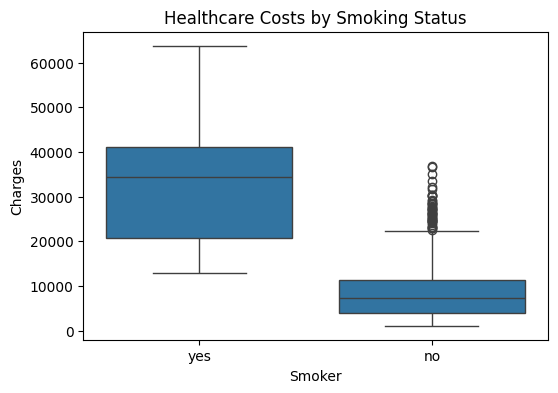

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Healthcare Costs by Smoking Status")
plt.xlabel("Smoker")
plt.ylabel("Charges")
plt.show()

The chart clearly highlights that smokers not only have higher average costs, but also a much wider distribution, reinforcing smoking as the main cost driver in the dataset.

### 5.2 Age and Healthcare Costs

The analysis examines how healthcare costs vary across **age groups**.

In [38]:
query = """
SELECT
  CASE WHEN age < 30 THEN '18-29'
      WHEN age < 40 THEN '30-39'
      WHEN age < 50 THEN '40-49'
      ELSE '50+'
    END AS age_group, COUNT(*) AS population, ROUND(AVG(charges),2) AS avg_cost
FROM insurance GROUP BY age_group ORDER BY age_group;
"""
pd.read_sql(query, conn)

,age_group,population,avg_cost
0,18-29,417,9182.49
1,30-39,257,11738.78
2,40-49,279,14399.20
3,50+,385,17902.55


* average costs from the youngest group: **\$9,182**

* average costs among individuals aged 50 and above: **\$17,903**

Healthcare costs increase steadily with age, showing a consistent upward trend.



### 5.3 BMI and Healthcare Costs

This analysis explores the relationship between Body Mass Index (**BMI**) and healthcare costs.

In [39]:
query = """
SELECT
  CASE WHEN bmi < 25 THEN 'Normal'
      WHEN bmi < 30 THEN 'Overweight'
      ELSE 'Obese'
    END AS bmi_category, COUNT(*) AS population, ROUND(AVG(charges),2) AS avg_cost
FROM insurance GROUP BY bmi_category ORDER BY avg_cost;
"""
pd.read_sql(query, conn)

,bmi_category,population,avg_cost
0,Normal,245,10282.22
1,Overweight,386,10987.51
2,Obese,707,15552.34


- normal BMI: **~\$10,300**
- obese: **~\$15,500**  
- obese group represents the largest portion of the dataset (**707** individuals against  **245** with normal BMI)

Higher BMI is associated with higher healthcare costs, suggesting that weight-related factors play an important role.

To better understand this relationship, the chart below shows how BMI relates to healthcare costs, also considering smoking status.

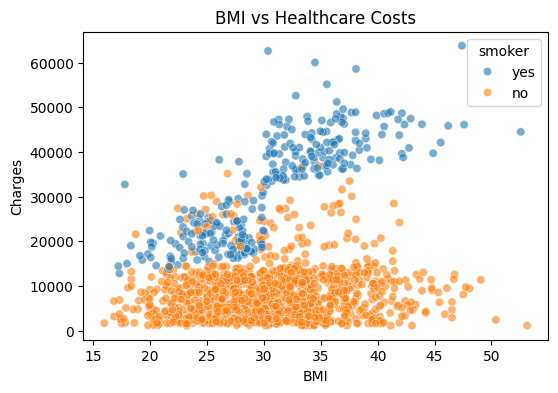

In [40]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="bmi", y="charges", hue="smoker", data=df, alpha=0.6)
plt.title("BMI vs Healthcare Costs")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

The chart shows that higher BMI values are associated with higher costs, especially among smokers, reinforcing the interaction between multiple risk factors.

### 5.4 Risk Interaction: Smoking and BMI

This analysis explores how risk factors interact with each other.

In [41]:
query = """
SELECT smoker,
  CASE WHEN bmi < 25 THEN 'Normal'
      WHEN bmi < 30 THEN 'Overweight'
      ELSE 'Obese'
    END AS bmi_category, COUNT(*) AS population, ROUND(AVG(charges),2) AS avg_cost
FROM insurance GROUP BY smoker, bmi_category ORDER BY avg_cost DESC;
"""
pd.read_sql(query, conn)

,smoker,bmi_category,population,avg_cost
0,yes,Obese,145,41557.99
1,yes,Overweight,74,22495.87
2,yes,Normal,55,19839.28
3,no,Obese,562,8842.69
4,no,Overweight,312,8257.96
5,no,Normal,190,7515.71


The interaction between smoking and BMI reveals one of the strongest patterns in the dataset:

- smokers with obesity leads to the highest costs per year: **~\$41,558**
- non-smokers with normal BMI leads the lowest costs: **\~$7,500**  

Risk factors **accumulate rather than act independently**, leading to significantly higher costs.

### 5.5 Distribution of Healthcare Costs

The histogram below illustrates the overall distribution of annual healthcare costs.

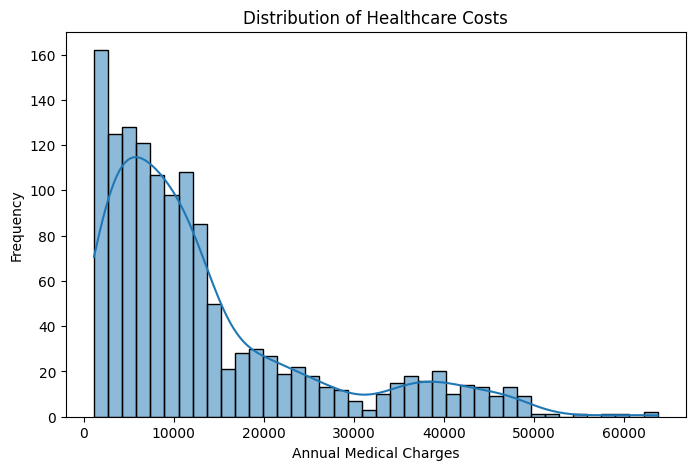

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=40, kde=True)
plt.title("Distribution of Healthcare Costs")
plt.xlabel("Annual Medical Charges")
plt.ylabel("Frequency")
plt.show()

The distribution is higly right-skewed.
- most individuals have annual costs between **\$1,000** and **\$15,000**  
- healthcare expenses above **\$30,000** are relatively rare
- a small group generate exceeds **\$60,000**

This indicates that a small portion of individuals generates a large share of total costs.

Overall, these visualizations reinforce the key patterns observed in the SQL analysis and highlight how a combination of lifestyle and demographic factors drives healthcare costs.

## 6. Risk Segmentation

To better understand how different factors contribute to healthcare costs, a simple risk segmentation approach is created.

Instead of analyzing each variable separately, we combine key risk factors into a single **risk score**, making it easier to identify higher-risk profiles.

### 6.1. Risk Score Definition

The **score** is based on three variables:

- smoking status  
- BMI above 30  
- age above 50  

Each individual receives:

- +2 points if the individual is a smoker
- +1 point if BMI > 30  
- +1 point if age > 50  

This creates a risk scale ranging from 0 (lowest risk) to 4 (highest risk).

In [43]:
df["risk_score"] = ((df["smoker"] == "yes").astype(int)*2 +(df["bmi"] > 30).astype(int) +(df["age"] > 50).astype(int))
df["risk_score"].value_counts().sort_index().rename(index=lambda x: f"Risk Score {x}").to_frame("count")

,count
risk_score,
Risk Score 0,392
Risk Score 1,491
Risk Score 2,285
Risk Score 3,132
Risk Score 4,38


* most individuals fall within the **lower risk categories (0-2)**
* a smaller portion belongs to the **highest risk levels (3-4)**.


### 6.2. Risk Score and Healthcare Costs

The next step is to evaluate how healthcare costs change across different **risk levels**.

In [44]:
result = df.groupby("risk_score")["charges"].mean()
result = result.rename(index=lambda x: f"Risk Score {x}").to_frame("Charges")
result["Charges"] = result["Charges"].map(lambda x: f"${x:,.0f}")
result

,Charges
risk_score,
Risk Score 0,"$6,477"
Risk Score 1,"$8,045"
Risk Score 2,"$16,066"
Risk Score 3,"$37,032"
Risk Score 4,"$47,369"



- risk score 0 (low risk): **~\$6,477**
- risk score 4 (high risk): **~\$47,369**

Healthcare costs increase significantly as risk factors accumulate, with high-risk individuals generating more than **7x higher costs**.

### 6.3. Visualizing Risk Score Impact
We visualize the relationship between the risk score and average healthcare costs.

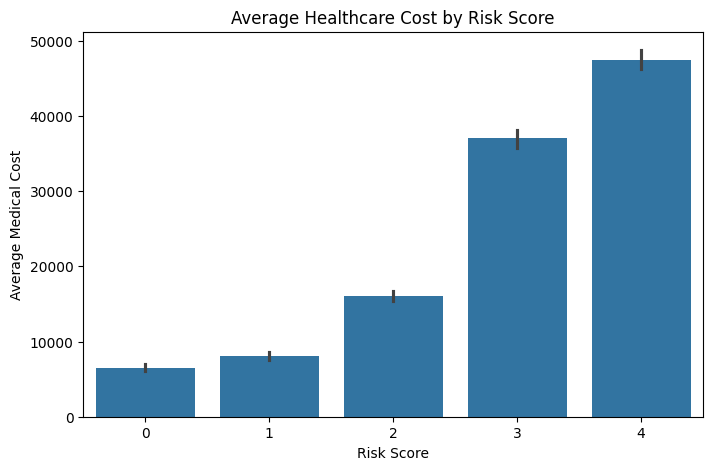

In [45]:
import numpy as np
plt.figure(figsize=(8,5))
sns.barplot(x="risk_score", y="charges", data=df, estimator= np.mean)
plt.title("Average Healthcare Cost by Risk Score")
plt.xlabel("Risk Score")
plt.ylabel("Average Medical Cost")
plt.show()

The chart shows a clear upward trend, with costs rising sharply as the risk score increases.

### 6.4 Key Insights

- risk factors do not act independently
- they **accumulate and amplify cost impact**
- a small high-risk segment drives a large portion of total costs

From a business perspective, this helps identify where risk is concentrated and supports more targeted strategies.



## 7. Customer Segmentation (Clustering)

Customer segmentation is a common technique in business analytics and consulting because it helps identify groups of individuals with similar characteristics and risk profiles.

In this step, we apply **K-Means clustering** to identify segments with similar characteristics and cost patterns.

The model considers the following variables:

- age
- BMI
- number of children
- healthcare costs

Before applying the clustering algorithm, the variables are standardized to ensure they are comparable.

In [46]:
from sklearn.preprocessing import StandardScaler
features = df[["age", "bmi", "children", "charges"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### 7.1 Determining the Number of Clusters using KMeans

The Elbow Method is used to determine the optimal number of clusters.

The method analyzes **inertia**, a metric that measures how closely data points are grouped within each cluster.



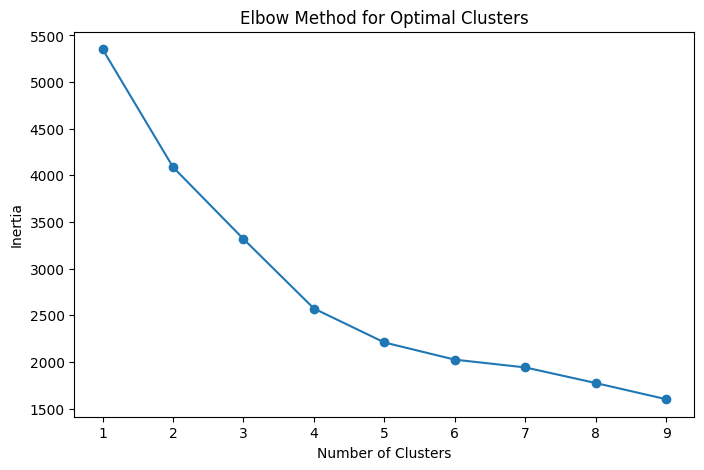

In [47]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(range(1,10), inertia, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

The curve suggests that **4 clusters** provide a good balance, where the curve begins to flatten.


### 7.2 Cluster Distribution

K-Means model was fitted using the standardized variables defined earlier. Each observation then receives a cluster label.



In [48]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts().sort_index().to_frame("count")

,count
cluster,
0,408
1,165
2,346
3,419


The clusters are relatively balanced in size, although **Cluster 1 is smaller**, suggesting a more specific subgroup.


### 7.3 Cluster Profiles

To interpret the clusters, we examine the **average characteristics of each group**.

In [49]:
df.groupby("cluster")[["age","bmi","children","charges"]].mean().round(1)

,age,bmi,children,charges
cluster,,,,
0,52.5,30.9,0.4,12593.0
1,39.9,35.3,1.1,40308.3
2,39.9,30.0,2.7,10709.6
3,25.4,29.2,0.4,5397.4


By analyzing average characteristics, we can interpret the segments:


**Cluster 0 – Older  segment**

- higher age
- slightly higher BMI
- moderate healthcare expenses
- likely driven by age-related factors

**Cluster 1 – High-risk segment**

- highest BMI values
- significantly higher costs
- average annual cots above **$40,000**
- likely associated with higher-risk profiles

**Cluster 2 – Family segment**

- middle-aged population
- higher number of children
- moderate costs
- relatively stable health profiles

**Cluster 3 – Young & low cost segment**

- youngest individuals
- relatively low BMI
- lowest costs (**\~$5,400**)
- generally lower risk profiles


### 7.4.Key Insights

- the population is not homogeneous
- different segments show distinct cost patterns
- one group clearly concentrates higher costs

This segmentation supports a better understanding of portfolio composition and enables more targeted strategies for different customer groups.

## 8. Causal Inference

The previous analysis showed a strong relationship between smoking and healthcare costs. However, correlation alone does not necessarily imply causation.

To better understand the impact of smoking, we apply **Propensity Score Matching (PSM)**.

The goal is to compare smokers and non-smokers with similar characteristics, reducing bias in the analysis.

### 8.1 Propensity Score Estimation

We first estimate the probability of being a smoker based on:

- age  
- BMI  
- number of children  


In [50]:
from sklearn.linear_model import LogisticRegression
X = df[["age","bmi","children"]]
y = (df["smoker"]=="yes").astype(int)
log_reg = LogisticRegression()
log_reg.fit(X,y)
df["propensity_score"] = log_reg.predict_proba(X)[:,1]
df[["propensity_score","smoker"]].head()

,propensity_score,smoker
0,0.215594,yes
1,0.222106,no
2,0.219995,no
3,0.202624,no
4,0.206018,no


Each individual receives a propensity score representing how likely they are to be a smoker given their characteristics.

### 8.2 Treatment and Control Groups

For the causal analysis, the dataset is divided into two groups:

- **treatment group:** smokers  
- **control group:** non-smokers  

In [51]:
smokers = df[df["smoker"] == "yes"]
non_smokers = df[df["smoker"] == "no"]
groups = pd.DataFrame({"Group": ["Non-smokers", "Smokers"],"Population": [len(non_smokers), len(smokers)]})
groups

,Group,Population
0,Non-smokers,1064
1,Smokers,274




Because the groups are very different in size, direct comparisons may be biased.

The next step is to match individuals with similar propensity scores to create comparable groups.

### 8.3 Estimated Causal Effect of Smoking

After matching smokers with non-smokers who have similar characteristics (age, BMI, and number of children), we compare their healthcare costs.


In [52]:
from sklearn.neighbors import NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=1).fit(non_smokers[["propensity_score"]])
indices = nbrs.kneighbors(smokers[["propensity_score"]], return_distance=False)
matched_df = smokers.copy()
matched_df["matched_cost"] = non_smokers.iloc[indices.flatten()]["charges"].values
pd.DataFrame({"Group": ["Smokers", "Matched Non-Smokers"],"Average Cost": [f"${matched_df['charges'].mean():,.0f}",f"${matched_df['matched_cost'].mean():,.0f}"]})

,Group,Average Cost
0,Smokers,"$32,050"
1,Matched Non-Smokers,"$8,541"


The results show a substantial difference between the two groups.

- average cost for smokers: **~\$32,050**  
- average cost for matched non-smokers: **~\$8,540**

This suggests that smoking is associated with an increase of  **~\$23,500** in annual healthcare costs per individual.

### 8.4. Key Insights

- part of the cost difference is explained by observable factors
- however, a large gap remains after controlling for these variables
- this indicates a strong impact of smoking on healthcare costs

From a business perspective, understanding causal drivers helps improve cost projections and identify factors that significantly impact claims.

## 9. Predictive Modeling (Regression)

In this step, we build predictive models to estimate healthcare costs based on demographic and lifestyle variables.

The goal is to understand how well costs can be predicted and which factors contribute most to these predictions.

To achieve this, two models are applied:

- **Linear Regression**, used as a baseline model  
- **Random Forest**, used to capture non-linear relationships and improve predictive performance  

These models help evaluate how well healthcare costs can be predicted and which variables contribute most to these predictions.

### 9.1. Model setup

The following variables are used as features:

- age  
- BMI  
- number of children  
- smoking status  
- gender  
- region  

Categorical variables are converted using one-hot encoding, using a reference category to avoid redundancy.
  

In [53]:
features = ["age","bmi","children","smoker","sex","region"]
df_model = pd.get_dummies(df[features], drop_first=True)
X = df_model
y = df["charges"]


To evaluate model performance, the dataset is divided into training and testing sets.

- **Training set:** 80% of the data  
- **Test set:** 20% of the data

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)
X_train.shape

(1070, 8)

### 9.2 Linear Regression (Baseline)

The first model trained is a Linear Regression, a commonly used baseline model for predicting healthcare costs.

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
results = pd.DataFrame({"Metric": ["MAE","RSME", "R²"],"Value": [f"${mae_lr:,.0f}", f"${rmse_lr:,.0f}", f"{r2_lr:.2f}"]})
results

,Metric,Value
0,MAE,"$4,181"
1,RSME,"$5,796"
2,R²,0.78


- the model explains approximately **78%** of the variance (**R²**) in healthcare costs, which indicates a strong relationship between the selected variables and medical expenses
- **MAE** (Mean Absolute Error) indicates that predictions are, on average, within **\$4,181** of the actual values
- **RMSE** (Root Mean Squared Error), which penalizes larger errors, is approximately **\$5,796**, suggesting that larger deviations remain limited

The model already captures a large portion of the relationship between demographic and lifestyle factors and medical expenses.

### 9.3 Random Forest Regressor

To capture more complex relationships between variables, we train a **Random Forest Regressor**, a model capable of handling non-linear interactions.

In [56]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
model_results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest"],"MAE": [f"${mae_lr:,.0f}", f"${mae_rf:,.0f}"],"RMSE": [f"${rmse_lr:,.0f}", f"${rmse_rf:,.0f}"],"R²": [f"{r2_lr:.2f}", f"{r2_rf:.2f}"]})
model_results

,Model,MAE,RMSE,R²
0,Linear Regression,"$4,181","$5,796",0.78
1,Random Forest,"$2,560","$4,589",0.86


The comparison of the model performance metrics shows that the Random Forest model improves predictive performance:

- **R²** increases from **0.78** to **0.86**  
- **MAE** decreases from **\$4,181** to **\$2,560**  
- **RMSE** decreases from **\$5,796** to **\$4,589**  

The improvement suggests that healthcare costs are influenced by non-linear interactions between variables, which Random Forest model captures more effectively.

### 9.4 Feature Importance

To better understand which variables contribute most to the model’s predictions, we examine feature importance from the Random Forest model.

Categorical variables are encoded using one-hot encoding with a reference category, so feature importance reflects the impact of each category relative to a baseline.

In [57]:
feature_table = (pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).reset_index().rename(columns={"index": "Feature", 0: "Importance"}))
feature_table["Importance"] = feature_table["Importance"].apply(lambda x: "<0.01" if x < 0.01 else f"{x:.2f}")
feature_table

,Feature,Importance
0,smoker_yes,0.61
1,bmi,0.21
2,age,0.13
3,children,0.02
4,sex_male,<0.01
5,region_northwest,<0.01
6,region_southeast,<0.01
7,region_southwest,<0.01


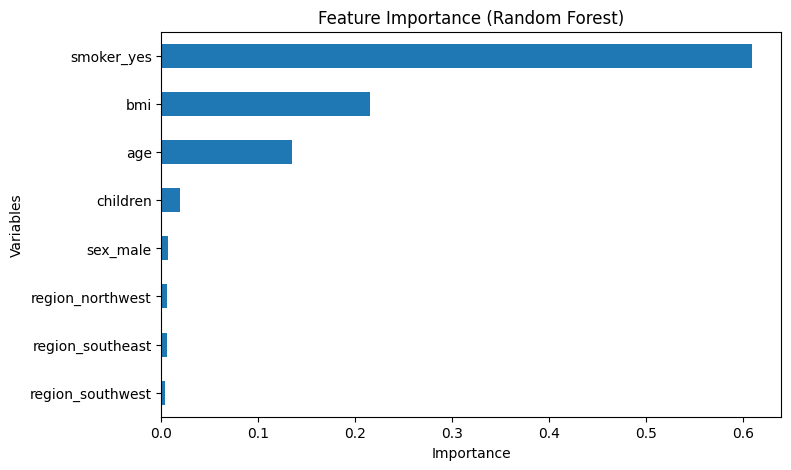

In [58]:
feature_importance = pd.Series(rf.feature_importances_,index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Variables")
plt.show()

* `smoking` is the strongest cost driver  (**~60%** importance)
* `BMI` is the second strongest predictor (**~20%** importance)
* `age` is also an important contributor (**~13%** importance)

Other variables such as region, gender, and number of children have relatively small effects on predicted healthcare costs.

### 9.5 Key Insights  
- **smoking is the strongest cost driver**, consistently identified across all analyses  
- BMI and age also play an important role in explaining healthcare costs  
- healthcare costs can be **predicted with good accuracy**, especially using non-linear models  
- a small number of variables explain most of the variation in costs  

The insights reinforce the patterns observed throughout the analysis and highlight how predictive models can support cost estimation, planning and risk assessment in an insurance context.

These results lead to the next step: moving from cost estimation to identifying which individuals are more likely to generate high-cost claims.

## 10. Claim Risk Modeling (Classification)

In addition to predicting costs, an important question in an insurance context is identifying which individuals are more likely to generate higher-cost claims.

To simulate this scenario, we create a binary variable using the feature `charges` representing **claim risk**, based on the distribution of healthcare costs.

To assess model performance, we consider:

- precision → how many predicted high-risk cases are actually high-risk  
- recall → how many real high-risk cases are correctly identified  
- F1-score → balance between precision and recall  

These metrics provide a more complete view than accuracy alone.

### 10.1 Defining Claim Risk and Model Setup

Individuals in the top 20% of costs are considered higher-risk cases.

- **1** -> higher-cost claim
- **0** -> lower-cost case

This allows us to frame the problem as a classification task.

In [59]:
threshold = df["charges"].quantile(0.8)
df["claim"] = (df["charges"] >= threshold).astype(int)

We use the same feature set defined in the previous section.

In [60]:
X = df_model
y = df["claim"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 10.2 Logistic Regression

This model provides a simple and interpretable baseline.

In [61]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
pred_log = log_model.predict(X_test)
from sklearn.metrics import classification_report
print("Model Evaluation (Logistic Regression):")
print("")
print(classification_report(y_test, pred_log))

Model Evaluation (Logistic Regression):

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       212
           1       0.90      0.79      0.84        56

    accuracy                           0.94       268
   macro avg       0.92      0.88      0.90       268
weighted avg       0.94      0.94      0.93       268



The model performs well as a baseline, with strong precision and good overall balance between precision and recall.

### 10.3 Random Forest Classifier

This model captures more complex patterns in the data.


In [62]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)
pred_rf = rf_clf.predict(X_test)
print("Model Evaluation (Random Forest):")
print("")
print(classification_report(y_test, pred_rf))

Model Evaluation (Random Forest):

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       212
           1       0.96      0.79      0.86        56

    accuracy                           0.95       268
   macro avg       0.95      0.89      0.92       268
weighted avg       0.95      0.95      0.95       268



The Random Forest model improves performance, especially in precision, reducing false positives while maintaining similar recall.

### 10.4 Key Insights  

Precision reflects how accurate high-risk predictions are, while recall indicates how many actual high-risk cases are identified.

- both models are able to distinguish higher-risk cases effectively  
- Random Forest improves **precision** (**0.96** vs **0.90**), reducing false positives  
- **recall** remains similar (**~0.79**), indicating that some high-risk cases are still missed  
- **F1-score** is slightly higher for Random Forest (**0.86** vs **0.84**), showing better overall balance  

From a business perspective, this helps identify where risk is concentrated and supports more targeted strategies in an insurance context.

In the next section, we explore how model predictions can be further adjusted using different probability thresholds to support decision-making.

## 11. Threshold Tuning and Decision Analysis

Instead of using only predicted labels, we analyze the predicted probabilities from the model to better control **how high-risk cases are identified**.

While the `claim` variable was defined using a fixed cost-based threshold (top 20%) in the previous section, here we focus on how model predictions can be adjusted using different probability thresholds.

These probabilities represent how likely each individual is to belong to the higher-risk group.

### 11.1 Probability Distribution

To better understand how these probabilities are distributed, the chart below shows the predicted probability of high-cost claims across individuals.

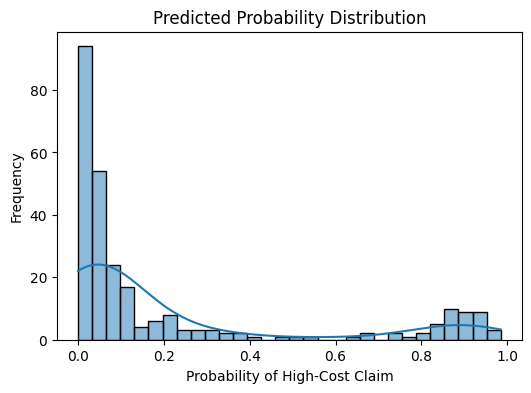

In [63]:
probs = rf_clf.predict_proba(X_test)[:,1]
plt.figure(figsize=(6,4))
sns.histplot(probs, bins=30, kde=True)
plt.title("Predicted Probability Distribution")
plt.xlabel("Probability of High-Cost Claim")
plt.ylabel("Frequency")
plt.show()

Most observations are concentrated at lower probability levels, while a smaller portion shows higher probabilities, indicating a limited group of individuals with elevated risk.

This distribution helps explain why adjusting the threshold does not significantly increase recall, as relatively few individuals fall into the higher probability range.

### 11.2 Threshold Comparison

By default, a threshold of **0.5** is used to classify observations. We compare it with a lower threshold (**0.4**) to evaluate its impact.


In [64]:
pred_05 = (probs > 0.5).astype(int)
pred_04 = (probs > 0.4).astype(int)
print("Threshold 0.5")
print(classification_report(y_test, pred_05))
print("Threshold 0.4")
print(classification_report(y_test, pred_04))

Threshold 0.5
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       212
           1       0.96      0.79      0.86        56

    accuracy                           0.95       268
   macro avg       0.95      0.89      0.92       268
weighted avg       0.95      0.95      0.95       268

Threshold 0.4
              precision    recall  f1-score   support

           0       0.95      0.98      0.96       212
           1       0.92      0.79      0.85        56

    accuracy                           0.94       268
   macro avg       0.93      0.88      0.90       268
weighted avg       0.94      0.94      0.94       268



- lowering the threshold from **0.5** to **0.4** does not increase **recall** (**0.79 vs. 0.79**), meaning no additional high-risk cases are effectively captured

- however, **precision** decreases when moving from threshold 0.5 to 0.4, increasing the number of false positives (**0.96 vs. 0.92**), meaning that using a lower threshold leads to more false alerts without improving risk detection

For this reason, the **default threshold (0.5) provides a better balance** between risk detection and false alerts, generating more reliable high-risk predictions without increasing unnecessary alerts.



## 12. Business Applications

The analysis provides practical insights that can support decision-making in an insurance context, including:

- **smoking is the strongest cost driver**, with costs nearly 4x higher than non-smokers  
- risk factors such as smoking, BMI and age accumulate, leading to exponential increases in costs  
- a small segment of **high-risk** individuals concentrates a large share of total healthcare expenses  
- **customer segmentation** reveals distinct profiles with very different cost behaviors  
- **predictive models** can estimate costs with good accuracy and identify higher-risk individuals  

In addition, threshold tuning shows how model outputs can be adjusted depending on business priorities, balancing risk detection and false alerts.

Overall, these results help move from descriptive analysis to more structured and actionable decision-making.

## 13. Limitations

Some limitations should be considered when interpreting the results of this analysis.

- the dataset is relatively small and may not fully represent real-world populations  
- only a limited number of variables are available, without detailed medical or behavioral information  
- the data is cross-sectional, meaning it does not capture changes over time  

In addition, the claim variable is derived from cost thresholds, which simplifies real insurance scenarios.

Despite these limitations, the analysis provides a useful approximation of how risk patterns can be explored using data.

## 14. Future Improvements

There are several ways this analysis could be extended.

- incorporating additional data sources, such as medical history or time-based data  
- testing other machine learning models and feature engineering techniques  
- improving claim definition using real-world insurance data  
- building interactive dashboards for better visualization and communication  

Another interesting extension would be to evaluate how these models perform in real decision scenarios, such as pricing or risk monitoring.

These improvements would help move the analysis closer to real-world applications.

## 15. Conclusion

This project explored how data analysis and predictive modeling can be used to better understand healthcare costs and risk patterns in an insurance context.

The results show that a small number of factors, especially smoking, BMI and age, explain a large part of cost variation, and that risk factors tend to accumulate rather than act independently.

Different analytical approaches provided complementary perspectives:

- **exploratory analysis** revealed strong cost patterns across groups  
- **segmentation** highlighted distinct customer profiles with different risk levels  
- **causal analysis** reinforced the impact of smoking on healthcare costs  
- **predictive models** enabled both cost estimation and risk identification  

One key insight is that high-cost cases are concentrated in a relatively small portion of the population, making early identification especially valuable.

Another important takeaway is that model performance is not only about accuracy, but about how predictions are used. The threshold analysis showed that different decision strategies can lead to different trade-offs between risk detection and false alerts.

Overall, this project illustrates how data can support more informed, structured and practical decision-making, connecting technical analysis with real-world applications.

This reinforces the role of analytics not only as a predictive tool, but as a key component in decision-making and strategic planning.